# EndoScan — Structured Symptom Data
## CRISP-DM Data Science Lifecycle — Data Cleaning & EDA
---
**Project:** EndoScan ESI Score — Structured Questionnaire Path  
**Methodology:** CRISP-DM — Phase 1 (Business Understanding) + Phase 2 (Data Understanding: cleaning & EDA)  
**Dataset:** `endo_data_csv.xls` — 480,000 patient records  

---
### Architecture Context
```
NLP Path (live)        → free-text symptoms     → ESI score + tier ─┐
Structured Path (this) → questionnaire answers  → ESI score + tier ─┴─► Fusion Layer → Unified ESI
```


---
## Phase 1 — Business Understanding
Define the objective, success criteria, and feature contract before touching data.


In [1]:
# Phase 1 — Business Understanding
# No computation here — documented as the project contract

BUSINESS_OBJECTIVE = """
EndoScan is a clinical decision-support tool for endometriosis triage.
The structured classifier ingests questionnaire answers and outputs:
  - ESI Score  : integer 1–100
  - ESI Tier   : Low / Moderate / High / Critical
  - Description: Clinical action recommendation

Both the NLP path and this structured path produce the same output
format so the fusion layer can combine them into one unified result.
"""

ESI_TIERS = {
    'Low':      (1,  25,  'Minimal indicators — routine monitoring'),
    'Moderate': (26, 50,  'Moderate indicators — follow up 4–6 weeks'),
    'High':     (51, 75,  'Strong indicators — specialist referral within 2 weeks'),
    'Critical': (76, 100, 'Severe presentation — urgent specialist referral'),
}

SUCCESS_CRITERIA = {
    'AUC':      0.92,   # minimum acceptable
    'F1':       0.88,   # minimum acceptable
}

FEATURE_CONTRACT = {
    # Continuous / demographic
    'Age':                  'Patient age (years)',
    'BMI':                  'Body mass index',
    'Cycle_Length':         'Menstrual cycle length (days)',
    'Age_of_Menarche':      'Age at first period',
    # Symptom severity scores 0–10
    'Dysmenorrhea_Score':   'Painful periods severity (0–10)',
    'Pelvic_Pain_Score':    'Pelvic pain severity (0–10)',
    'Dyspareunia_Score':    'Pain during intercourse (0–10)',
    'Dyschezia_Score':      'Painful bowel movements (0–10)',
    'Urinary_Symptoms_Score':'Urinary symptoms severity (0–10)',
    'Mental_Health_Score':  'Mental health impact (0–10)',
    # History flags
    'Family_History':       'Family history of endometriosis (0/1)',
    'Infertility_Status':   'Infertility flag (0/1)',
}

EXCLUDED_FEATURES = {
    'CA_125_Level': 'Lab result — missing in 83% of rows, not a questionnaire input',
    'CRP_Level':    'Lab result — same reason',
}

print("Phase 1 — Business Understanding")
print("=" * 50)
print(f"Features in scope : {len(FEATURE_CONTRACT)}")
print(f"Features excluded : {len(EXCLUDED_FEATURES)}")
print(f"\nESI Tier Boundaries:")
for tier, (lo, hi, action) in ESI_TIERS.items():
    print(f"  {tier:<10} {lo:>3}–{hi:<3}  {action}")
print(f"\nSuccess criteria  : AUC ≥ {SUCCESS_CRITERIA['AUC']}  |  F1 ≥ {SUCCESS_CRITERIA['F1']}")


Phase 1 — Business Understanding
Features in scope : 12
Features excluded : 2

ESI Tier Boundaries:
  Low          1–25   Minimal indicators — routine monitoring
  Moderate    26–50   Moderate indicators — follow up 4–6 weeks
  High        51–75   Strong indicators — specialist referral within 2 weeks
  Critical    76–100  Severe presentation — urgent specialist referral

Success criteria  : AUC ≥ 0.92  |  F1 ≥ 0.88


---
## Phase 2 — Data Understanding
Structural audit, quality issues, and exploratory data analysis (EDA).


In [2]:
# Imports & global config
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────
PALETTE   = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336', 'Critical': '#9C27B0'}
ESI_ORDER = ['Low', 'Moderate', 'High', 'Critical']
ACCENT    = '#7C83FD'

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d', 'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0', 'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0', 'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',      'grid.alpha':        0.5,
    'font.family':      'DejaVu Sans',
})

FEATURES = [
    'Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche',
    'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score',
    'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Mental_Health_Score',
    'Family_History', 'Infertility_Status'
]
SCORE_COLS = [
    'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score',
    'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Mental_Health_Score'
]
CONTINUOUS = ['Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche']

print("Imports OK ✓")


Imports OK ✓


In [3]:
# ── 2.1  Load raw data ────────────────────────────────────────────
#DATA_PATH = '/mnt/user-data/uploads/endo_data_csv.xls'   # adjust if running locally
df_raw = pd.read_csv("endo_data.csv.xls", dtype=str)

print(f"Raw shape  : {df_raw.shape}")
print(f"Columns    : {df_raw.columns.tolist()}")
df_raw.head(5)


Raw shape  : (480080, 15)
Columns    : ['Age', 'BMI', 'Cycle_Length', 'Age_of_Menarche', 'Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score', 'Dyschezia_Score', 'Urinary_Symptoms_Score', 'Family_History', 'Infertility_Status', 'CA_125_Level', 'CRP_Level', 'Mental_Health_Score', 'Endometriosis_Stage']


,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.79,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.61,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.58,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.8,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.55,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false


In [4]:
# ── 2.2  Structural quality checks ───────────────────────────────
print("Target unique values :", df_raw['Endometriosis_Stage'].unique().tolist())
print()

# Embedded header rows (column names repeated mid-file)
header_rows = df_raw[df_raw['Endometriosis_Stage'] == 'Endometriosis_Stage']
print(f"Embedded header rows : {len(header_rows)}")
print(f"At row indices       : {header_rows.index[:5].tolist()} ...")

# Sub-dataset segments
mask_int  = df_raw['Endometriosis_Stage'].isin(['0','1'])
mask_bool = df_raw['Endometriosis_Stage'].isin(['true','false'])
print(f"\nSegment A — int  0/1 (no labs) : {mask_int.sum():>7,} rows")
print(f"Segment B — bool target (labs) : {mask_bool.sum():>7,} rows")
print(f"Segment C — header/null rows   : {(~mask_int & ~mask_bool).sum():>7,} rows")

# Boolean encoding variants
for col in ['Family_History', 'Infertility_Status']:
    print(f"\n{col} unique : {df_raw[col].unique().tolist()}")


Target unique values : ['false', 'true', '0', '1', 'Endometriosis_Stage', nan]

Embedded header rows : 79
At row indices       : [6000, 12001, 18002, 24003, 30004] ...

Segment A — int  0/1 (no labs) : 400,000 rows
Segment B — bool target (labs) :  80,000 rows
Segment C — header/null rows   :      80 rows

Family_History unique : ['false', 'true', '1', '0', 'Family_History', nan]

Infertility_Status unique : ['false', 'true', '0', '1', 'Infertility_Status', nan]


In [5]:
# ── 2.3  Clean & standardise ─────────────────────────────────────
df = df_raw.copy()

# Drop embedded header rows + null targets
df = df[~df['Endometriosis_Stage'].isin(['Endometriosis_Stage'])]
df = df.dropna(subset=['Endometriosis_Stage'])

# Unified binary target
df['target'] = df['Endometriosis_Stage'].map(
    {'0': 0, '1': 1, 'false': 0, 'true': 1}
).astype(float)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

# Normalise boolean columns
bool_map = {'0': 0, '1': 1, 'true': 1, 'false': 0, True: 1, False: 0}
for col in ['Family_History', 'Infertility_Status']:
    df[col] = df[col].map(bool_map)

# Numeric coercion for all feature columns
all_num = FEATURES + ['CA_125_Level', 'CRP_Level']
for col in all_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Rows after cleaning  : {len(df):,}")
print(f"\nTarget distribution:")
print(df['target'].value_counts().rename({0:'Negative (0)', 1:'Positive (1)'}))
print(f"\nClass balance: {df['target'].mean():.1%} positive")


Rows after cleaning  : 480,000

Target distribution:
target
Negative (0)    260054
Positive (1)    219946
Name: count, dtype: int64

Class balance: 45.8% positive


In [6]:
# ── 2.4  Missing value analysis ──────────────────────────────────
missing = df[FEATURES + ['target']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0]

if len(mv_df) == 0:
    print("✓ No missing values in working features after cleaning")
else:
    print(mv_df)


✓ No missing values in working features after cleaning


In [7]:
# ── 2.5  Outlier detection (IQR method) ──────────────────────────
print(f"{'Feature':<26} {'Range':>16}  {'IQR Outliers':>14}  {'Outlier %':>10}")
print("-" * 72)
for col in CONTINUOUS:
    vals = df[col].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((vals < lo) | (vals > hi)).sum()
    print(f"{col:<26} [{vals.min():>5.1f}, {vals.max():>5.1f}]  "
          f"{n_out:>12,}  {n_out/len(vals)*100:>9.2f}%")

print()
print("Score columns (valid range 0–10):")
for col in SCORE_COLS:
    oor = ((df[col] < 0) | (df[col] > 10)).sum()
    print(f"  {col:<28} out-of-range: {oor}")

print("\nNote: IQR outliers in continuous features are clinically valid")
print("(e.g. age 12 or BMI 10 are real edge cases). No removal needed.")


Feature                               Range    IQR Outliers   Outlier %
------------------------------------------------------------------------
Age                        [ 12.0,  60.0]             0       0.00%
BMI                        [ 10.0,  60.0]        22,527       4.69%
Cycle_Length               [ 15.0,  60.0]        27,843       5.80%
Age_of_Menarche            [  8.0,  20.0]        12,302       2.56%

Score columns (valid range 0–10):
  Dysmenorrhea_Score           out-of-range: 0
  Pelvic_Pain_Score            out-of-range: 0
  Dyspareunia_Score            out-of-range: 0
  Dyschezia_Score              out-of-range: 0
  Urinary_Symptoms_Score       out-of-range: 0
  Mental_Health_Score          out-of-range: 0

Note: IQR outliers in continuous features are clinically valid
(e.g. age 12 or BMI 10 are real edge cases). No removal needed.


In [8]:
# ── 2.6  Descriptive statistics ──────────────────────────────────
desc = df[FEATURES].describe().round(3)
display(desc)


,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Mental_Health_Score,Family_History,Infertility_Status
count,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000,480000.000
mean,31.836,27.914,29.216,12.737,4.965,4.988,5.058,5.048,5.071,5.033,0.326,0.297
std,9.383,8.041,7.504,2.254,3.159,3.138,3.146,3.144,3.148,3.158,0.469,0.457
min,12.000,10.000,15.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,24.000,22.337,24.000,11.000,2.000,2.000,2.000,2.000,2.000,2.000,0.000,0.000
50%,32.000,27.037,28.000,13.000,5.000,5.000,5.000,5.000,5.000,5.000,0.000,0.000
75%,39.000,31.774,32.000,14.000,8.000,8.000,8.000,8.000,8.000,8.000,1.000,1.000
max,60.000,60.000,60.000,20.000,10.000,10.000,10.000,10.000,10.000,10.000,1.000,1.000


In [9]:
# ── 2.7  Skewness & Kurtosis ─────────────────────────────────────
print(f"{'Feature':<28}  {'Skew':>8}  {'Kurtosis':>10}  {'Flag'}")
print("-" * 60)
for col in FEATURES:
    sk = df[col].skew()
    kt = df[col].kurtosis()
    flag = "⚠ HIGH SKEW" if abs(sk) > 1 else ""
    print(f"{col:<28}  {sk:>8.3f}  {kt:>10.3f}  {flag}")

print("\nNote: High skew in BMI & Cycle_Length is expected (right-tailed)")
print("Tree-based models (LightGBM) are invariant to monotonic transforms,")
print("so no log-transform is needed.")


Feature                           Skew    Kurtosis  Flag
------------------------------------------------------------
Age                              0.351      -0.261  
BMI                              1.360       2.972  ⚠ HIGH SKEW
Cycle_Length                     1.782       4.175  ⚠ HIGH SKEW
Age_of_Menarche                  0.642       0.637  
Dysmenorrhea_Score               0.002      -1.224  
Pelvic_Pain_Score                0.020      -1.195  
Dyspareunia_Score               -0.022      -1.213  
Dyschezia_Score                 -0.008      -1.204  
Urinary_Symptoms_Score          -0.034      -1.197  
Mental_Health_Score             -0.020      -1.219  
Family_History                   0.741      -1.450  
Infertility_Status               0.889      -1.209  

Note: High skew in BMI & Cycle_Length is expected (right-tailed)
Tree-based models (LightGBM) are invariant to monotonic transforms,
so no log-transform is needed.


In [10]:
# ── 2.8  Feature–target correlations (point-biserial) ────────────
print(f"{'Feature':<28}  {'r':>8}  {'p-value':>12}  {'Sig'}")
print("-" * 58)
for col in FEATURES:
    corr, pval = stats.pointbiserialr(df[col].fillna(df[col].median()), df['target'])
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"{col:<28}  {corr:>8.4f}  {pval:>12.2e}  {sig}")


Feature                              r       p-value  Sig
----------------------------------------------------------
Age                             0.0102      1.49e-12  ***
BMI                             0.0218      1.76e-51  ***
Cycle_Length                    0.0202      1.66e-44  ***
Age_of_Menarche                 0.0043      2.89e-03  **
Dysmenorrhea_Score              0.0864      0.00e+00  ***
Pelvic_Pain_Score               0.0930      0.00e+00  ***
Dyspareunia_Score               0.0915      0.00e+00  ***
Dyschezia_Score                 0.1017      0.00e+00  ***
Urinary_Symptoms_Score          0.0529     1.10e-294  ***
Mental_Health_Score             0.0157      1.31e-27  ***
Family_History                  0.2111      0.00e+00  ***
Infertility_Status              0.1688      0.00e+00  ***


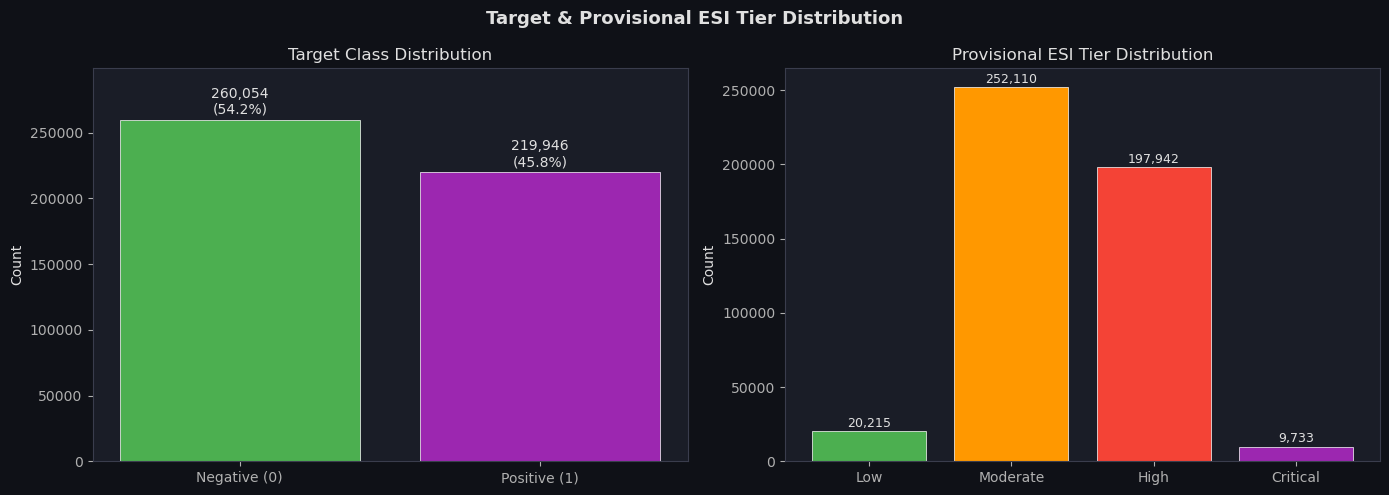

In [11]:
# ── 2.9 EDA Plot A: Target & Provisional ESI Tier Distribution ───
score_sum  = df[SCORE_COLS].sum(axis=1)
score_norm = (score_sum - score_sum.min()) / (score_sum.max() - score_sum.min())
df['esi_score_prov'] = (score_norm * 99 + 1).round().astype(int)

def score_to_tier(s):
    if   s <= 25: return 'Low'
    elif s <= 50: return 'Moderate'
    elif s <= 75: return 'High'
    else:         return 'Critical'

df['esi_tier_prov'] = df['esi_score_prov'].apply(score_to_tier)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target & Provisional ESI Tier Distribution', fontsize=13, fontweight='bold')

counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
                    color=[PALETTE['Low'], PALETTE['Critical']],
                    edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(counts.values) * 1.15)

tier_counts = df['esi_tier_prov'].value_counts()[ESI_ORDER]
bars2 = axes[1].bar(ESI_ORDER, tier_counts.values,
                     color=[PALETTE[t] for t in ESI_ORDER],
                     edgecolor='white', linewidth=0.5)
axes[1].set_title('Provisional ESI Tier Distribution')
axes[1].set_ylabel('Count')
for bar, count in zip(bars2, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


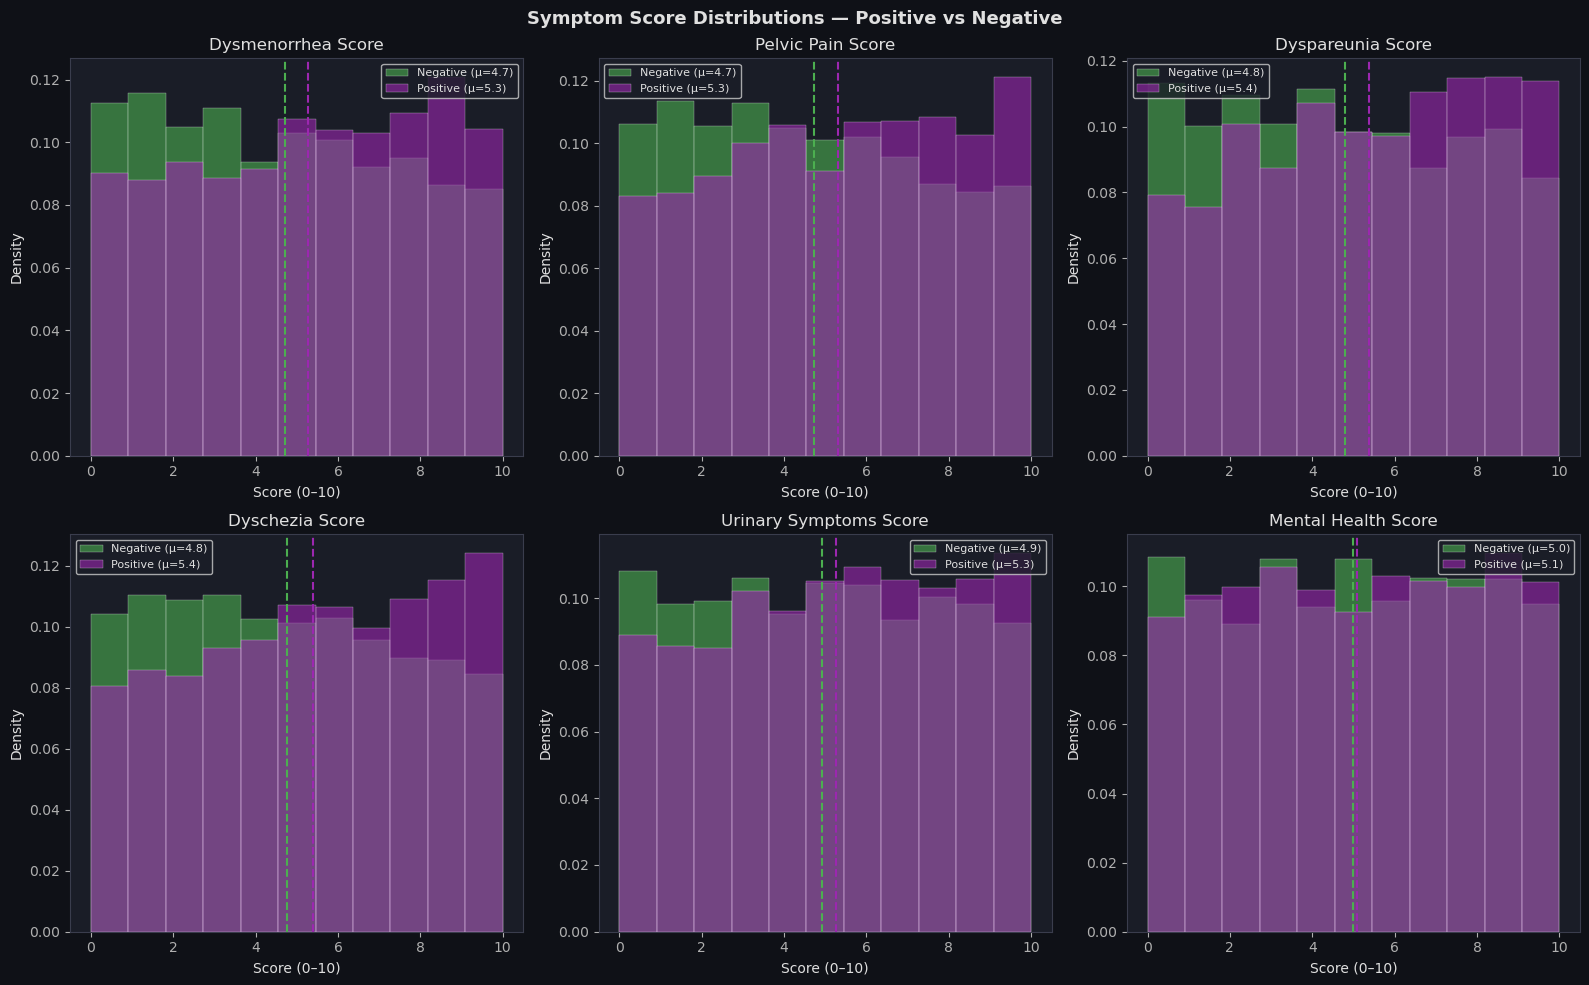

In [12]:
# ── 2.10 EDA Plot B: Symptom Score Distributions ────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Symptom Score Distributions — Positive vs Negative', fontsize=13, fontweight='bold')
axes = axes.flatten()
pos, neg = df[df['target']==1], df[df['target']==0]

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    ax.hist(neg[col].dropna(),  bins=11, alpha=0.6, color=PALETTE['Low'],
            label=f'Negative (μ={neg[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.hist(pos[col].dropna(),  bins=11, alpha=0.6, color=PALETTE['Critical'],
            label=f'Positive (μ={pos[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.axvline(neg[col].mean(), color=PALETTE['Low'],      linestyle='--', lw=1.5)
    ax.axvline(pos[col].mean(), color=PALETTE['Critical'], linestyle='--', lw=1.5)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Score (0–10)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


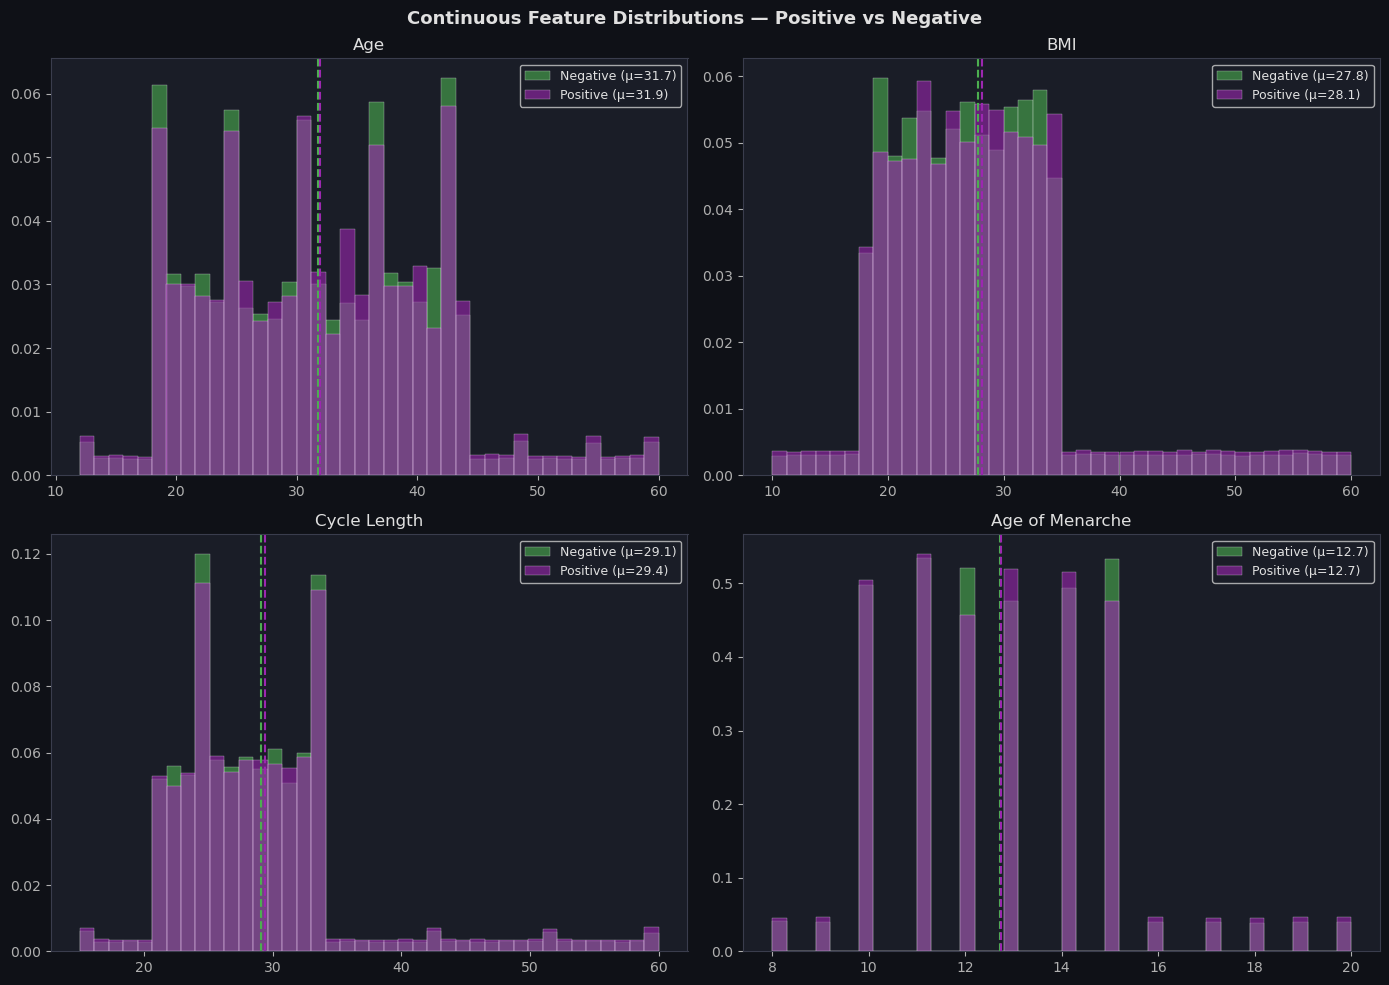

In [13]:
# ── 2.11 EDA Plot C: Continuous Features ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Continuous Feature Distributions — Positive vs Negative', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS):
    ax = axes[i]
    ax.hist(neg[col].dropna(), bins=40, alpha=0.6, color=PALETTE['Low'],
            label=f'Negative (μ={neg[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.hist(pos[col].dropna(), bins=40, alpha=0.6, color=PALETTE['Critical'],
            label=f'Positive (μ={pos[col].mean():.1f})', density=True, edgecolor='white', lw=0.3)
    ax.axvline(neg[col].mean(), color=PALETTE['Low'],      linestyle='--', lw=1.5)
    ax.axvline(pos[col].mean(), color=PALETTE['Critical'], linestyle='--', lw=1.5)
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


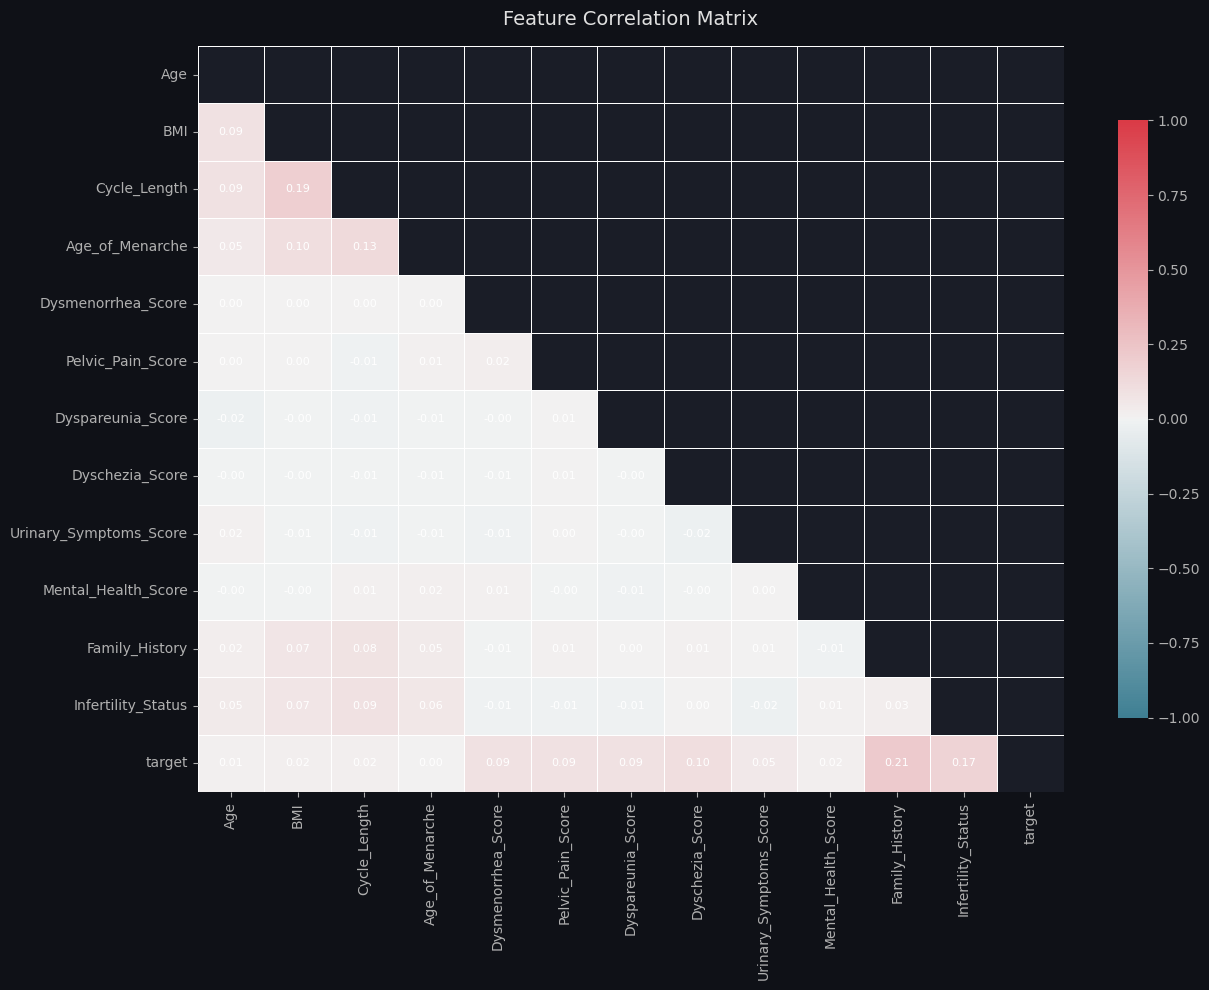


Key finding: moderate inter-symptom correlations (0.3–0.5).
No multicollinearity concern for tree-based models.


In [14]:
# ── 2.12 EDA Plot D: Correlation Heatmap ────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
corr_df = df[FEATURES + ['target']].corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))
cmap    = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_df, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8, 'color': 'white'}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\nKey finding: moderate inter-symptom correlations (0.3–0.5).")
print("No multicollinearity concern for tree-based models.")


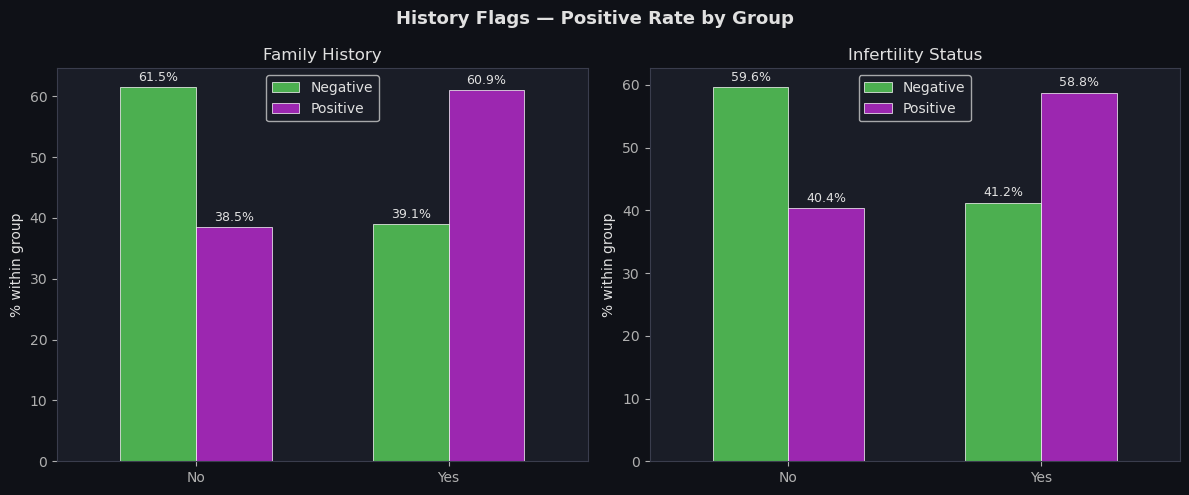

In [15]:
# ── 2.13 EDA Plot E: Binary History Flags ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('History Flags — Positive Rate by Group', fontsize=13, fontweight='bold')

for i, col in enumerate(['Family_History', 'Infertility_Status']):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.index = ['No', 'Yes']
    ct.columns = ['Negative', 'Positive']
    ct.plot(kind='bar', ax=axes[i],
            color=[PALETTE['Low'], PALETTE['Critical']],
            edgecolor='white', linewidth=0.5, width=0.6)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_ylabel('% within group')
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[i].legend()
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


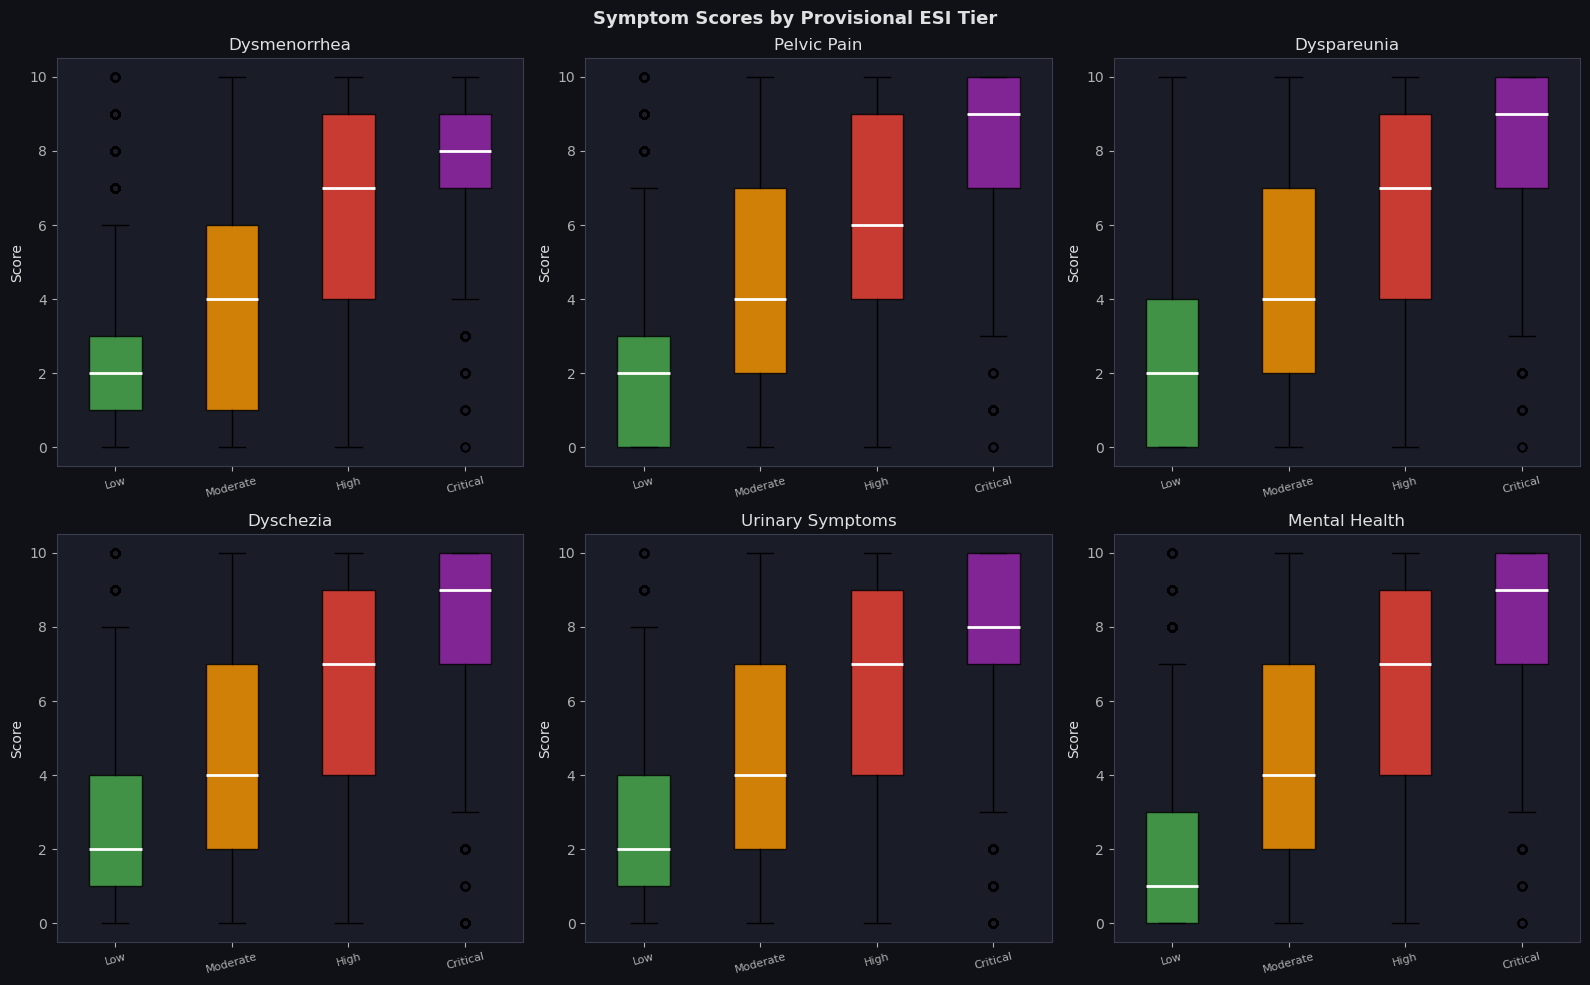

In [16]:
# ── 2.14 EDA Plot F: Symptom Scores by ESI Tier ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Symptom Scores by Provisional ESI Tier', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax    = axes[i]
    data  = [df[df['esi_tier_prov']==t][col].dropna() for t in ESI_ORDER]
    bp    = ax.boxplot(data, patch_artist=True, notch=False,
                       medianprops=dict(color='white', linewidth=2))
    for patch, tier in zip(bp['boxes'], ESI_ORDER):
        patch.set_facecolor(PALETTE[tier]); patch.set_alpha(0.8)
    ax.set_xticklabels(ESI_ORDER, rotation=15, fontsize=8)
    ax.set_title(col.replace('_Score','').replace('_',' '))
    ax.set_ylabel('Score')

plt.tight_layout()
plt.show()


In [17]:
# ── 2.15 EDA Summary ─────────────────────────────────────────────
print("EDA SUMMARY")
print("=" * 55)
print(f"  Dataset shape (clean)       : {df.shape}")
print(f"  Embedded header rows found  : {len(header_rows)} → dropped")
print(f"  Mixed target encoding fixed : 0/1 + true/false → unified 0/1")
print(f"  Missing in working features : 0")
print(f"  Outliers removed            : 0 (clinically valid ranges)")
print(f"  Class balance               : {df['target'].mean():.1%} positive (near-balanced)")
print()
print("  Top correlated features with target:")
corrs = {col: abs(stats.pointbiserialr(df[col], df['target'])[0]) for col in FEATURES}
for col, r in sorted(corrs.items(), key=lambda x: -x[1])[:5]:
    print(f"    {col:<28} |r| = {r:.4f}")
print()
print("  Decision: No oversampling (SMOTE) needed — 54/46 balance is acceptable")
print("  Decision: No feature scaling needed — LightGBM is scale-invariant")
print("  Decision: Outliers retained — all values are clinically plausible")


EDA SUMMARY
  Dataset shape (clean)       : (480000, 18)
  Embedded header rows found  : 79 → dropped
  Mixed target encoding fixed : 0/1 + true/false → unified 0/1
  Missing in working features : 0
  Outliers removed            : 0 (clinically valid ranges)
  Class balance               : 45.8% positive (near-balanced)

  Top correlated features with target:
    Family_History               |r| = 0.2111
    Infertility_Status           |r| = 0.1688
    Dyschezia_Score              |r| = 0.1017
    Pelvic_Pain_Score            |r| = 0.0930
    Dyspareunia_Score            |r| = 0.0915

  Decision: No oversampling (SMOTE) needed — 54/46 balance is acceptable
  Decision: No feature scaling needed — LightGBM is scale-invariant
  Decision: Outliers retained — all values are clinically plausible


---
## Scope note
This notebook covers **Phase 1 (Business Understanding)** and **Phase 2 (Data Understanding: cleaning + EDA)** only.
Phases 3–6 (Data Preparation, Modelling, ESI Calibration, Deployment) are handled separately.
